## 2) Install libraries

This notebook uses:
- `textblob` for a simple sentiment feature
- `scikit-learn` for the ML baseline
- `joblib` to save the best model

Since you already uploaded `twcs.csv` directly to Colab, this version does **not** download the dataset from Kaggle inside the notebook.


In [ ]:
!pip -q install textblob scikit-learn matplotlib seaborn joblib

## 3) Configure the CSV path

This notebook assumes you already uploaded the dataset file directly to Colab.

Expected file:
- `/content/twcs.csv`

If your file is in a different location, change `CSV_PATH` below.


In [ ]:
from pathlib import Path

CSV_PATH = Path("/content/twcs.csv")

print("CSV path:", CSV_PATH)
print("File exists:", CSV_PATH.exists())


CSV path: /content/twcs.csv
File exists: True


In [ ]:
# Optional safety check
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Could not find the dataset at {CSV_PATH}. "
        "Upload twcs.csv to Colab, or change CSV_PATH to the correct location."
    )


## 4) Load only a preview first

The dataset is large, so we inspect a small sample before any full processing.


In [ ]:
import pandas as pd

preview_df = pd.read_csv(CSV_PATH, nrows=5)
preview_df

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2.0,3
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1.0,4
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3.0,5
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4.0,6


In [ ]:
print("Columns:", preview_df.columns.tolist())
print("Shape of preview sample:", preview_df.shape)

Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']
Shape of preview sample: (5, 7)


## 4) Load only a preview first

The dataset is large, so we inspect a small sample before any full processing.

In [ ]:
import pandas as pd

preview_df = pd.read_csv(CSV_PATH, nrows=5)
preview_df

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2.0,3
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1.0,4
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3.0,5
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4.0,6


In [ ]:
preview_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tweet_id                 5 non-null      int64  
 1   author_id                5 non-null      object 
 2   inbound                  5 non-null      bool   
 3   created_at               5 non-null      object 
 4   text                     5 non-null      object 
 5   response_tweet_id        4 non-null      float64
 6   in_response_to_tweet_id  5 non-null      int64  
dtypes: bool(1), float64(1), int64(2), object(3)
memory usage: 377.0+ bytes


## 6) Column overview

Expected columns:
- `tweet_id`
- `author_id`
- `inbound`
- `created_at`
- `text`
- `response_tweet_id`
- `in_response_to_tweet_id`

For this project, the most important columns are:
- `text`
- `inbound`
- `created_at`

We mainly treat **inbound tweets** as support tickets.

## 7) Fast row counting without loading everything into memory

In [ ]:
import csv

with open(CSV_PATH, "r", encoding="utf-8", errors="ignore") as f:
    total_rows = sum(1 for _ in f) - 1

print("Approx total rows:", total_rows)

Approx total rows: 139719


## 8) Read the file in chunks and keep only useful rows

This is the first major optimization:
- keep only the needed columns
- process in chunks
- focus on **inbound tweets**
- drop missing or empty text
- strip whitespace

In [ ]:
USE_COLS = ["tweet_id", "author_id", "inbound", "created_at", "text"]

def clean_basic_text(text: str) -> str:
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ")
    text = " ".join(text.split())
    return text.strip()

chunk_iter = pd.read_csv(
    CSV_PATH,
    usecols=USE_COLS,
    chunksize=100_000
)

processed_chunks = []
inbound_count = 0

for chunk in chunk_iter:
    chunk = chunk.copy()
    chunk = chunk[chunk["text"].notna()]
    chunk["text"] = chunk["text"].astype(str).map(clean_basic_text)
    chunk = chunk[chunk["text"].str.len() > 0]
    chunk = chunk[chunk["inbound"] == True]
    inbound_count += len(chunk)
    processed_chunks.append(chunk)

df_inbound = pd.concat(processed_chunks, ignore_index=True)
print("Inbound rows kept:", len(df_inbound))
df_inbound.head()

Inbound rows kept: 73299


,tweet_id,author_id,inbound,created_at,text
0,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that
1,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...
2,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.
3,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service
4,12,115713,True,Tue Oct 31 22:04:47 +0000 2017,@sprintcare You gonna magically change your co...


## 9) Quick quality checks

In [ ]:
df_inbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73299 entries, 0 to 73298
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   tweet_id    73299 non-null  int64 
 1   author_id   73299 non-null  object
 2   inbound     73299 non-null  bool  
 3   created_at  73299 non-null  object
 4   text        73299 non-null  object
dtypes: bool(1), int64(1), object(3)
memory usage: 2.3+ MB


In [ ]:
df_inbound["text_len"] = df_inbound["text"].str.len()
df_inbound["word_count"] = df_inbound["text"].str.split().str.len()

print(df_inbound["text_len"].describe())
print(df_inbound["word_count"].describe())

count    73299.000000
mean       116.880326
std         64.617548
min          3.000000
25%         67.000000
50%        111.000000
75%        148.000000
max        397.000000
Name: text_len, dtype: float64
count    73299.000000
mean        19.942796
std         11.989298
min          1.000000
25%         11.000000
50%         19.000000
75%         26.000000
max         68.000000
Name: word_count, dtype: float64


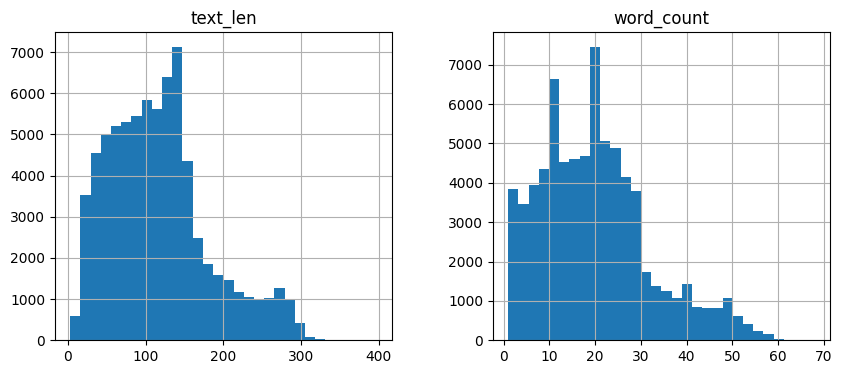

In [ ]:
df_inbound[["text_len", "word_count"]].hist(figsize=(10, 4), bins=30);

## 10) Optional filtering for ticket-like text

We remove extremely short texts because many of them are not useful for retrieval or modeling.

In [ ]:
df_inbound = df_inbound[df_inbound["text_len"] >= 15].copy()
df_inbound = df_inbound.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Rows after min-length and dedup:", len(df_inbound))
df_inbound.head()

Rows after min-length and dedup: 72528


,tweet_id,author_id,inbound,created_at,text,text_len,word_count
0,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,45,9
1,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,82,14
2,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,18,3
3,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service,41,6
4,12,115713,True,Tue Oct 31 22:04:47 +0000 2017,@sprintcare You gonna magically change your co...,89,16


## 11) Create a weak supervision label for ticket priority

The dataset has **no official priority label**, so we create one using a simple, transparent rule.

A tweet is labeled **urgent** if it has strong urgency signals such as:
- urgency/problem keywords
- multiple exclamation marks
- ALL-CAPS emphasis
- words like refund/cancel/broken/help/asap

This is **weak supervision**, not human ground truth.

In [ ]:
import re

URGENT_KEYWORDS = {
    "refund", "cancel", "charged", "charge", "broken", "down",
    "help", "asap", "urgent", "not working", "failed", "error",
    "issue", "problem", "hacked", "locked", "lock", "stolen",
    "cannot", "can't", "cant", "still waiting", "no response"
}

def urgency_keyword_count(text: str) -> int:
    t = text.lower()
    count = 0
    for kw in URGENT_KEYWORDS:
        if kw in t:
            count += 1
    return count

def count_all_caps_words(text: str) -> int:
    tokens = re.findall(r"\b[A-Z]{2,}\b", text)
    return len(tokens)

def weak_priority_label(text: str) -> int:
    lower = text.lower()
    kw_count = urgency_keyword_count(text)
    exclam_count = text.count("!")
    caps_count = count_all_caps_words(text)

    urgent = (
        kw_count >= 1
        or exclam_count >= 3
        or caps_count >= 2
    )
    return int(urgent)

df_inbound["keyword_count"] = df_inbound["text"].map(urgency_keyword_count)
df_inbound["exclamation_count"] = df_inbound["text"].str.count("!")
df_inbound["question_count"] = df_inbound["text"].str.count("\?")
df_inbound["all_caps_words"] = df_inbound["text"].map(count_all_caps_words)
df_inbound["priority_label"] = df_inbound["text"].map(weak_priority_label)

df_inbound["priority_label"].value_counts(normalize=True)

<>:37: SyntaxWarning: invalid escape sequence '\?'
<>:37: SyntaxWarning: invalid escape sequence '\?'
/tmp/ipykernel_4089/1225781837.py:37: SyntaxWarning: invalid escape sequence '\?'
  df_inbound["question_count"] = df_inbound["text"].str.count("\?")


,proportion
priority_label,
0,0.554613
1,0.445387


## 12) Analyze label balance

In [ ]:
label_counts = df_inbound["priority_label"].value_counts()
label_props = df_inbound["priority_label"].value_counts(normalize=True)

print("Counts:")
print(label_counts)
print("\nProportions:")
print(label_props)

Counts:
priority_label
0    40225
1    32303
Name: count, dtype: int64

Proportions:
priority_label
0    0.554613
1    0.445387
Name: proportion, dtype: float64


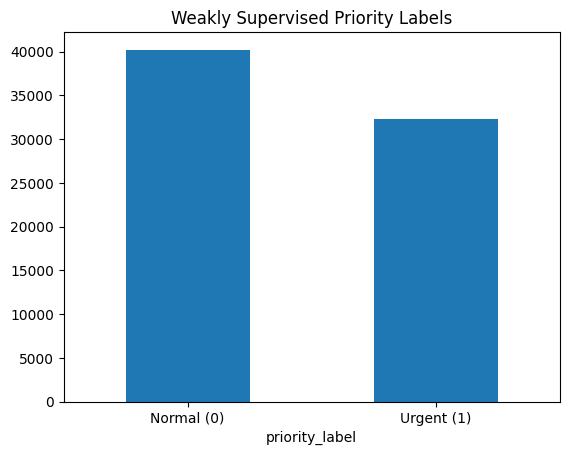

In [ ]:
import matplotlib.pyplot as plt

label_counts.sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Normal (0)", "Urgent (1)"], rotation=0)
plt.title("Weakly Supervised Priority Labels")
plt.show()

## 13) Build engineered features for the ML baseline

We use simple tabular features so the baseline is cheap, fast, and explainable.

In [ ]:
from textblob import TextBlob

def uppercase_ratio(text: str) -> float:
    letters = [c for c in text if c.isalpha()]
    if not letters:
        return 0.0
    upper = sum(1 for c in letters if c.isupper())
    return upper / len(letters)

def repeated_punct_count(text: str) -> int:
    return len(re.findall(r"([!?])\1+", text))

def contains_refund(text: str) -> int:
    return int("refund" in text.lower())

def contains_cancel(text: str) -> int:
    return int("cancel" in text.lower())

def contains_help(text: str) -> int:
    lower = text.lower()
    return int(("help" in lower) or ("support" in lower))

def contains_problem(text: str) -> int:
    lower = text.lower()
    vocab = ["broken", "error", "issue", "problem", "failed", "down", "not working"]
    return int(any(v in lower for v in vocab))

def sentiment_polarity(text: str) -> float:
    try:
        return TextBlob(text).sentiment.polarity
    except:
        return 0.0

feature_df = df_inbound.copy()

feature_df["uppercase_ratio"] = feature_df["text"].map(uppercase_ratio)
feature_df["repeated_punct_count"] = feature_df["text"].map(repeated_punct_count)
feature_df["contains_refund"] = feature_df["text"].map(contains_refund)
feature_df["contains_cancel"] = feature_df["text"].map(contains_cancel)
feature_df["contains_help"] = feature_df["text"].map(contains_help)
feature_df["contains_problem"] = feature_df["text"].map(contains_problem)
feature_df["sentiment_polarity"] = feature_df["text"].map(sentiment_polarity)

if "created_at" in feature_df.columns:
    feature_df["created_at"] = pd.to_datetime(feature_df["created_at"], errors="coerce")
    feature_df["hour_of_day"] = feature_df["created_at"].dt.hour.fillna(-1)
else:
    feature_df["hour_of_day"] = -1

ML_FEATURES = [
    "text_len",
    "word_count",
    "keyword_count",
    "exclamation_count",
    "question_count",
    "all_caps_words",
    "uppercase_ratio",
    "repeated_punct_count",
    "contains_refund",
    "contains_cancel",
    "contains_help",
    "contains_problem",
    "sentiment_polarity",
    "hour_of_day"
]

feature_df[ML_FEATURES + ["priority_label"]].head()

/tmp/ipykernel_4089/1861261967.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  feature_df["created_at"] = pd.to_datetime(feature_df["created_at"], errors="coerce")


,text_len,word_count,keyword_count,exclamation_count,question_count,all_caps_words,uppercase_ratio,repeated_punct_count,contains_refund,contains_cancel,contains_help,contains_problem,sentiment_polarity,hour_of_day,priority_label
0,45,9,0,0,0,0,0.000000,0,0,0,0,0,0.000000,22,0
1,82,14,0,0,0,0,0.014706,0,0,0,0,0,-0.083333,22,0
2,18,3,0,0,0,0,0.071429,0,0,0,0,0,0.000000,21,0
3,41,6,0,0,0,0,0.000000,0,0,0,0,0,-1.000000,21,0
4,89,16,0,0,1,0,0.014286,0,0,0,0,0,0.350000,22,0


## 14) Sample for faster training

Even after filtering, the dataset can still be large.  
For the ML baseline, we train on a **representative subset** to keep the notebook practical.

In [ ]:
TRAINING_SAMPLE_SIZE = 250_000

if len(feature_df) > TRAINING_SAMPLE_SIZE:
    model_df = feature_df.sample(TRAINING_SAMPLE_SIZE, random_state=42).reset_index(drop=True)
else:
    model_df = feature_df.copy()

print("Rows used for ML baseline:", len(model_df))
model_df["priority_label"].value_counts(normalize=True)

Rows used for ML baseline: 72528


,proportion
priority_label,
0,0.554613
1,0.445387


## 15) Train / validation split

In [ ]:
from sklearn.model_selection import train_test_split

X = model_df[ML_FEATURES]
y = model_df["priority_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((58022, 14), (14506, 14))

## 16) Train several ML models

We compare:
- Logistic Regression
- Random Forest
- Gradient Boosting

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import time

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model)
    ])

    start = time.perf_counter()
    pipeline.fit(X_train, y_train)
    train_time = time.perf_counter() - start

    pred_start = time.perf_counter()
    y_pred = pipeline.predict(X_test)
    pred_time = time.perf_counter() - pred_start

    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "train_time_sec": train_time,
        "predict_time_sec_total": pred_time,
        "avg_predict_time_ms_per_row": (pred_time / len(X_test)) * 1000
    }
    results.append(row)

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df

,model,accuracy,precision,recall,f1,train_time_sec,predict_time_sec_total,avg_predict_time_ms_per_row
1,RandomForest,1.000000,1.000000,1.000000,1.000000,9.014452,0.189543,0.013067
2,GradientBoosting,1.000000,1.000000,1.000000,1.000000,6.329147,0.028639,0.001974
0,LogisticRegression,0.996346,0.994597,0.997214,0.995904,3.975460,0.011634,0.000802


## 17) Choose the best model and inspect it

In [ ]:
best_model_name = results_df.iloc[0]["model"]
best_model_name

'RandomForest'

In [ ]:
best_model = models[best_model_name]

from sklearn.pipeline import Pipeline

best_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)
best_preds = best_pipeline.predict(X_test)

print(classification_report(y_test, best_preds, digits=4))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      8045
           1     1.0000    1.0000    1.0000      6461

    accuracy                         1.0000     14506
   macro avg     1.0000    1.0000    1.0000     14506
weighted avg     1.0000    1.0000    1.0000     14506



## 18) Save the best trained model

This file can later be loaded by your FastAPI backend.

In [ ]:
import joblib
from pathlib import Path

ARTIFACTS_DIR = Path("./artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

MODEL_PATH = ARTIFACTS_DIR / "priority_model.joblib"
FEATURES_PATH = ARTIFACTS_DIR / "ml_features.json"

joblib.dump(best_pipeline, MODEL_PATH)

import json
with open(FEATURES_PATH, "w") as f:
    json.dump(ML_FEATURES, f, indent=2)

print("Saved model to:", MODEL_PATH)
print("Saved feature list to:", FEATURES_PATH)

Saved model to: artifacts/priority_model.joblib
Saved feature list to: artifacts/ml_features.json


## 19) Prepare a smaller high-quality subset for RAG

For retrieval, we do **not** need all rows.  
We prepare a smaller subset that is:
- inbound
- non-empty
- cleaned
- deduplicated
- reasonably informative

In [ ]:
RAG_SAMPLE_SIZE = 75_000

rag_df = df_inbound.copy()
rag_df = rag_df[rag_df["text_len"] >= 25].copy()

if len(rag_df) > RAG_SAMPLE_SIZE:
    rag_df = rag_df.sample(RAG_SAMPLE_SIZE, random_state=42).reset_index(drop=True)

rag_df = rag_df[["tweet_id", "author_id", "created_at", "text", "priority_label"]].copy()
print("RAG subset shape:", rag_df.shape)
rag_df.head()

RAG subset shape: (70556, 5)


,tweet_id,author_id,created_at,text,priority_label
0,2,115712,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,0
1,3,115712,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,0
3,8,115712,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service,0
4,12,115713,Tue Oct 31 22:04:47 +0000 2017,@sprintcare You gonna magically change your co...,0
5,16,115713,Tue Oct 31 20:00:43 +0000 2017,@sprintcare Since I signed up with you....Sinc...,0


## 20) Save the RAG subset

This CSV can later be ingested into your vector store.

In [ ]:
RAG_PATH = ARTIFACTS_DIR / "rag_subset.csv"
rag_df.to_csv(RAG_PATH, index=False)

print("Saved RAG subset to:", RAG_PATH)

Saved RAG subset to: artifacts/rag_subset.csv


## 21) Optional: generate embeddings later

You can keep embeddings **outside this notebook** if you want to control API cost.  
If you later use:
- OpenAI embeddings
- sentence-transformers
- another local embedding model

you can ingest `rag_subset.csv` into Qdrant or Chroma from your backend pipeline.

## 22) Example zero-shot prompt for LLM priority prediction

This is not executed here by default, because it would require an API key and cost money.

In [ ]:
ZERO_SHOT_PRIORITY_PROMPT = '''
You are classifying customer support ticket urgency.

Return only one label:
- urgent
- normal

Ticket:
"{ticket_text}"
'''.strip()

print(ZERO_SHOT_PRIORITY_PROMPT)

You are classifying customer support ticket urgency.

Return only one label:
- urgent
- normal

Ticket:
"{ticket_text}"
